In [37]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import (train_test_split, GridSearchCV, cross_val_score)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
import shap

In [38]:
data = pd.read_csv("Data/Sample_Data/sample_data.csv")

In [39]:
X = data.drop(columns=['Label', 'BinaryLabel'])
y = data['BinaryLabel']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

lr_prob = lr_model.predict_proba(X_test_scaled)[:,1]

In [42]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

lr_cv_scores = cross_val_score(
    lr_pipeline,
    X,
    y,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [43]:
rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best F1 score:", grid_search.best_score_)

rf_model = grid_search.best_estimator_
 
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

Fitting 3 folds for each of 24 candidates, totalling 72 fits


KeyboardInterrupt: 

In [ ]:
rf_cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

print("Random Forest CV Scores:", rf_cv_scores)
print("Average RF CV F1-score:", rf_cv_scores.mean())

Random Forest CV Scores: [0.99560018 0.99554045 0.99588214 0.99552215 0.99544219]
Average RF CV F1-score: 0.9955974200706159


In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight='balanced',
    random_state=42,
    max_iter=5000
)

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)

In [ ]:
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='linear', class_weight='balanced', random_state=42))
])

svm_cv_scores = cross_val_score(
    svm_pipeline,
    X,
    y,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [ ]:
svm_scores = svm_model.decision_function(X_test_scaled)

In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, svm_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, svm_pred)
    ],
    'F1-score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, svm_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, svm_scores)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.85358,0.952079,0.74464,0.835679,0.958172
1,Random Forest,0.99526,0.994726,0.99580,0.995263,0.999854
2,SVM,0.85362,0.954828,0.74236,0.835295,0.957898


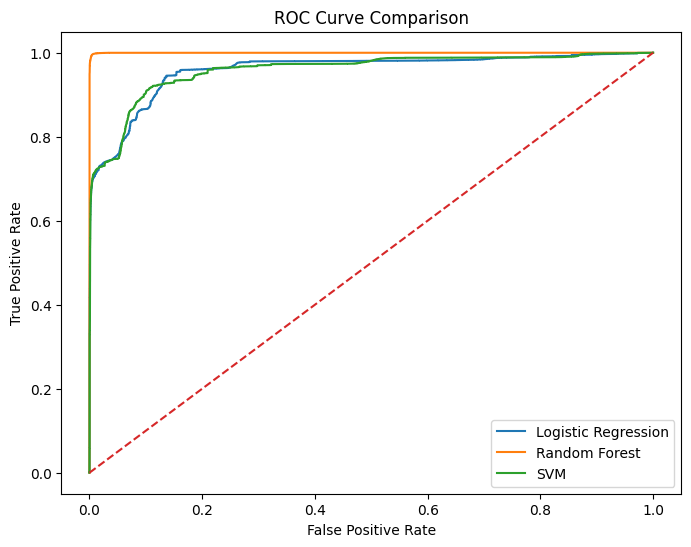

In [ ]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_scores)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot(fpr_svm, tpr_svm, label='SVM')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
lr_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
})

lr_importance = lr_importance.sort_values(by='Coefficient', ascending=False)

print(lr_importance.head(10))

                        Feature  Coefficient
14            Packet Length Std    13.103293
11                 Flow IAT Max     6.893769
13           Packet Length Mean     6.440798
1             Total Fwd Packets     4.091291
9                 Flow IAT Mean     2.198458
3   Total Length of Fwd Packets     1.372231
8                Flow Packets/s    -0.028604
7                  Flow Bytes/s    -0.701833
12                 Flow IAT Min    -1.861294
0                 Flow Duration    -2.555985


In [ ]:
perm_result = permutation_importance(
    rf_model,
    X_test,
    y_test,
    scoring='f1',
    n_repeats=5,
    random_state=42
)

perm_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_result.importances_mean
}).sort_values(by='Importance', ascending=False)

perm_importance.head(10)

,Feature,Importance
14,Packet Length Std,0.065157
6,Bwd Packet Length Mean,0.014069
1,Total Fwd Packets,0.008019
2,Total Backward Packets,0.007344
12,Flow IAT Min,0.003516
4,Total Length of Bwd Packets,0.003232
10,Flow IAT Std,0.003073
9,Flow IAT Mean,0.002780
11,Flow IAT Max,0.002212
0,Flow Duration,0.002051


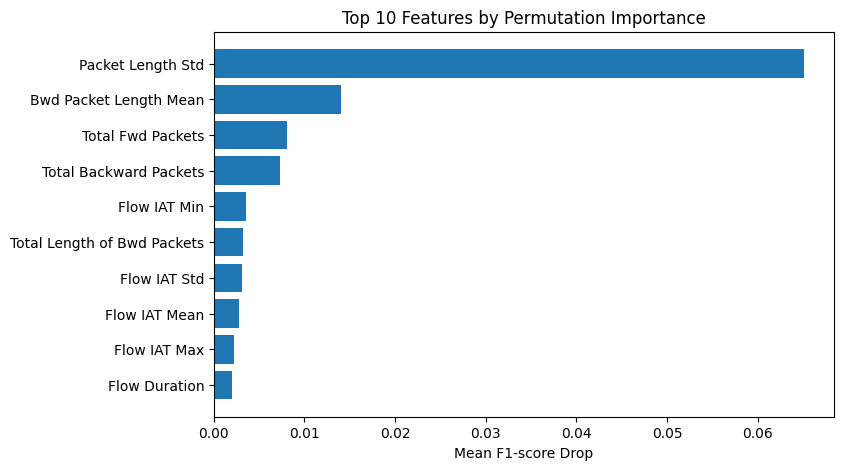

In [ ]:
top_perm = perm_importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_perm['Feature'], top_perm['Importance'])
plt.xlabel("Mean F1-score Drop")
plt.title("Top 10 Features by Permutation Importance")
plt.gca().invert_yaxis()
plt.show()

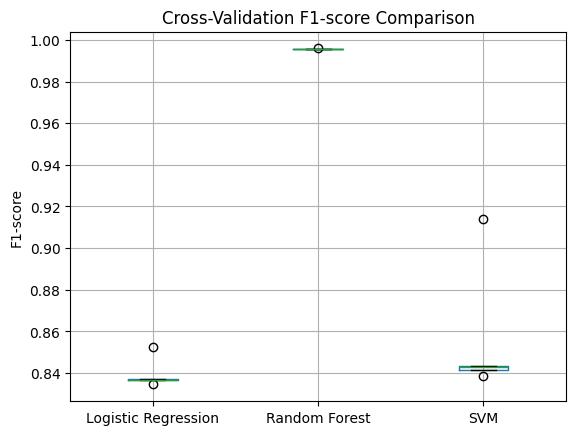

In [ ]:
cv_results = pd.DataFrame({
    'Logistic Regression': lr_cv_scores,
    'Random Forest': rf_cv_scores,
    'SVM': svm_cv_scores
})

cv_results.boxplot()

plt.title("Cross-Validation F1-score Comparison")

plt.ylabel("F1-score")

plt.show()

Sample shape: (200, 16)
SHAP shape: (200, 16, 2)


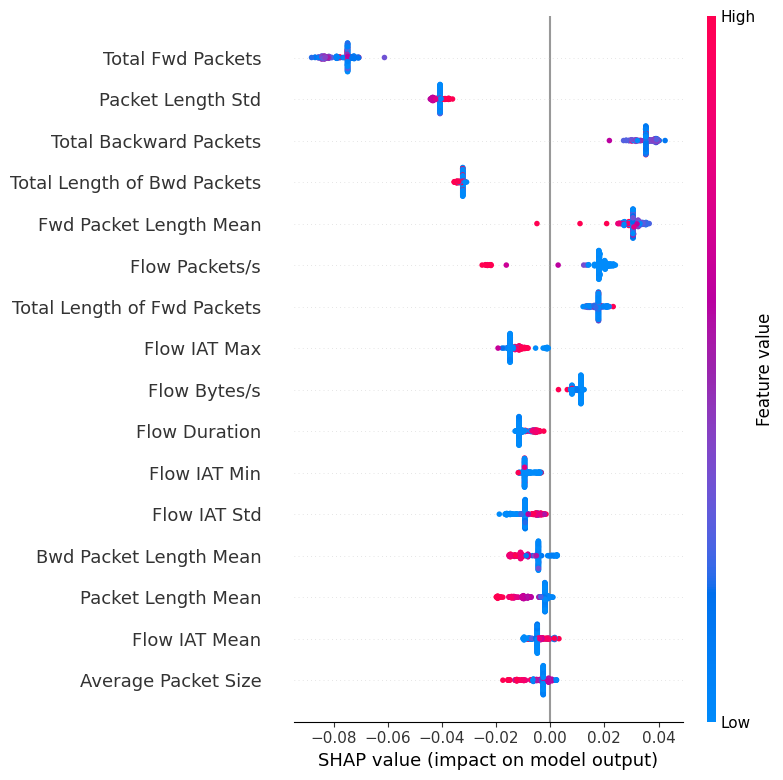

In [ ]:
import shap
import pandas as pd

# Use a small sample so it does not cook your Mac
sample = X_test_scaled[:200]

# Convert sample back into a DataFrame with column names
sample_df = pd.DataFrame(sample, columns=X.columns)

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(sample_df)

print("Sample shape:", sample_df.shape)

if isinstance(shap_values, list):
    print("SHAP shape:", shap_values[1].shape)
    shap.summary_plot(shap_values[1], sample_df)
else:
    print("SHAP shape:", shap_values.shape)

    # For newer SHAP versions with binary classifier output shape:
    if len(shap_values.shape) == 3:
        shap.summary_plot(shap_values[:, :, 1], sample_df)
    else:
        shap.summary_plot(shap_values, sample_df)
        

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.show()